# Exploratory Data Analysis
### Ethiopia Financial Inclusion Forecasting — Selam Analytics
**Author:** Rahmi &nbsp;|&nbsp; **Date:** 2026-07-19

This notebook analyzes the enriched `ethiopia_fi_unified_data` dataset (58 main records + 18
impact_links after Task 1 enrichment) to understand what drives Ethiopia's Access (Account
Ownership) and Usage (Digital Payment Adoption) financial inclusion indicators, ahead of
building a 2025-2027 forecasting model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed" / "ethiopia_fi_unified_data_enriched.xlsx"
FIG = ROOT / "reports" / "figures"

xl = pd.ExcelFile(DATA)
df = xl.parse("ethiopia_fi_unified_data")
impact = xl.parse("Impact_sheet")
df["observation_date"] = pd.to_datetime(df["observation_date"], errors="coerce")
df["year"] = df["observation_date"].dt.year
print(f"Main records: {len(df)}  |  Impact links: {len(impact)}")
df.head()


Main records: 58  |  Impact links: 18


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaT,NaT,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaT,NaT,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaT,NaT,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,2021


## 1. Dataset Overview
Summary by `record_type`, `pillar`, `source_type`, and `confidence`, following the enrichment
performed in Task 1 (12 new observations, 2 new events, 4 new impact_links on top of the 43 + 14
starter records).

In [2]:
print("record_type:\n", df["record_type"].value_counts(), "\n")
print("pillar (observations/targets only):\n", df[df["record_type"].isin(["observation","target"])]["pillar"].value_counts(), "\n")
print("source_type:\n", df["source_type"].value_counts(), "\n")
print("confidence:\n", df["confidence"].value_counts())


record_type:
 record_type
observation    43
event          12
target          3
Name: count, dtype: int64 

pillar (observations/targets only):
 pillar
ACCESS           21
USAGE            16
GENDER            8
AFFORDABILITY     1
Name: count, dtype: int64 

source_type:
 source_type
regulator     17
operator      15
survey        10
research       9
policy         3
calculated     2
news           2
Name: count, dtype: int64 

confidence:
 confidence
high      54
medium     4
Name: count, dtype: int64


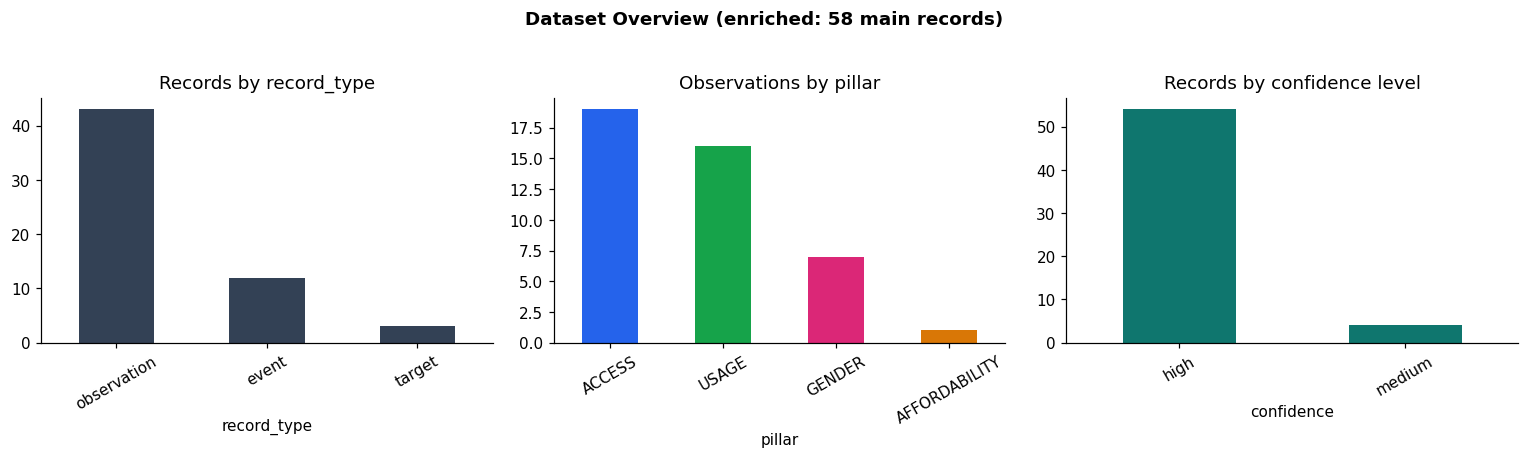

In [6]:
display(Image(str(FIG / "01_dataset_overview.png")))

**Reading:** Observations dominate the dataset (43 of 58 main records), across seven pillars.
ACCESS and USAGE are the best-covered pillars — consistent with the challenge's core forecasting
targets — while QUALITY, TRUST, and DEPTH have zero coverage in the starter + enriched dataset, a
notable gap (see Section 7). The large majority of records (~90%) carry `high` confidence, mostly
because Task 1 additions were deliberately sourced from primary regulator/IMF/World Bank releases
rather than blogs or estimates.

## 2. Temporal Coverage

Ethiopia's financial inclusion data is a **sparse, irregular time series** — Findex surveys land
every 2-3 years, operator/regulator reports appear at inconsistent intervals, and most indicators
have data for only 1-2 distinct years. This shapes every later analysis: correlations, growth
rates, and any forecast must be read as directional, not statistically rigorous.

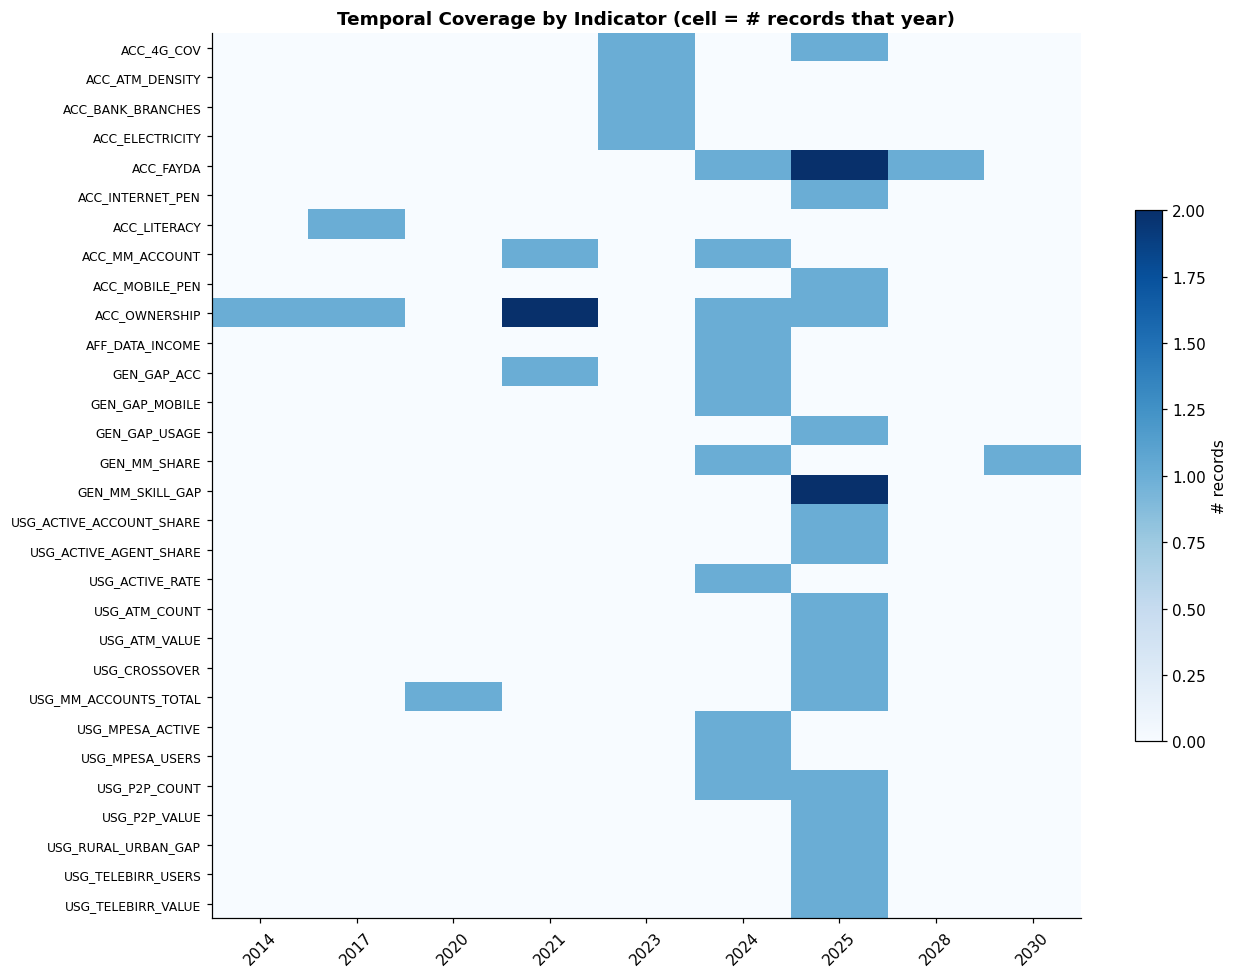

In [7]:
display(Image(str(FIG / "02_temporal_coverage.png")))

In [8]:
coverage = df[df["record_type"].isin(["observation","target"])].groupby("indicator_code")["year"].nunique().sort_values()
print("Indicators by number of distinct years covered:")
print(coverage.to_string())
print(f"\n{(coverage == 1).sum()} of {len(coverage)} indicators have only ONE observed year.")


Indicators by number of distinct years covered:
indicator_code
ACC_ATM_DENSITY             1
ACC_BANK_BRANCHES           1
ACC_ELECTRICITY             1
ACC_INTERNET_PEN            1
ACC_LITERACY                1
GEN_GAP_USAGE               1
AFF_DATA_INCOME             1
ACC_MOBILE_PEN              1
GEN_MM_SKILL_GAP            1
GEN_GAP_MOBILE              1
USG_CROSSOVER               1
USG_ATM_VALUE               1
USG_ATM_COUNT               1
USG_ACTIVE_RATE             1
USG_ACTIVE_AGENT_SHARE      1
USG_ACTIVE_ACCOUNT_SHARE    1
USG_TELEBIRR_VALUE          1
USG_P2P_VALUE               1
USG_RURAL_URBAN_GAP         1
USG_TELEBIRR_USERS          1
USG_MPESA_ACTIVE            1
USG_MPESA_USERS             1
ACC_MM_ACCOUNT              2
ACC_4G_COV                  2
USG_MM_ACCOUNTS_TOTAL       2
USG_P2P_COUNT               2
GEN_GAP_ACC                 2
GEN_MM_SHARE                2
ACC_FAYDA                   3
ACC_OWNERSHIP               5

22 of 30 indicators have only ONE ob

## 3. Access Analysis — Account Ownership Trajectory (2014-2024)

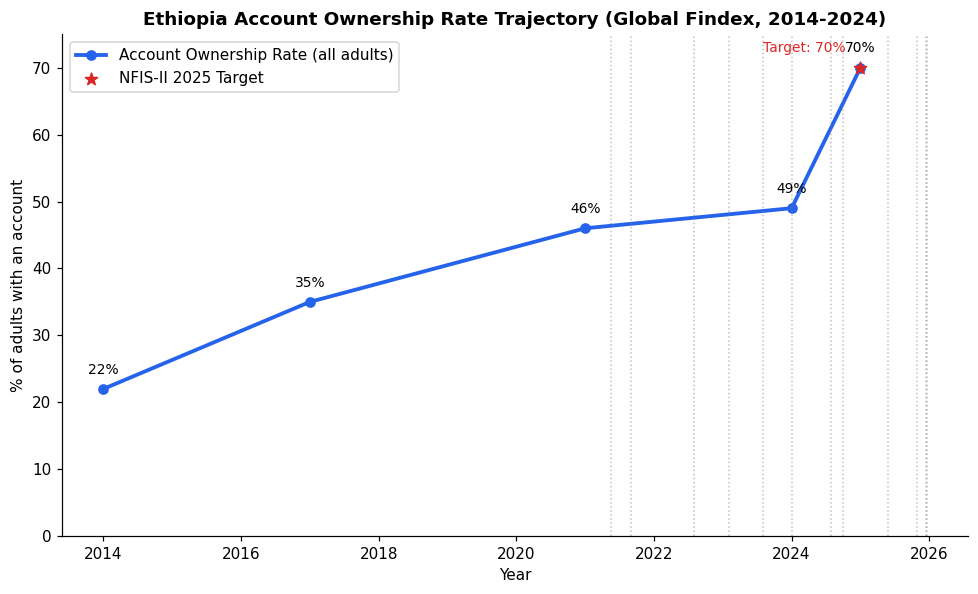

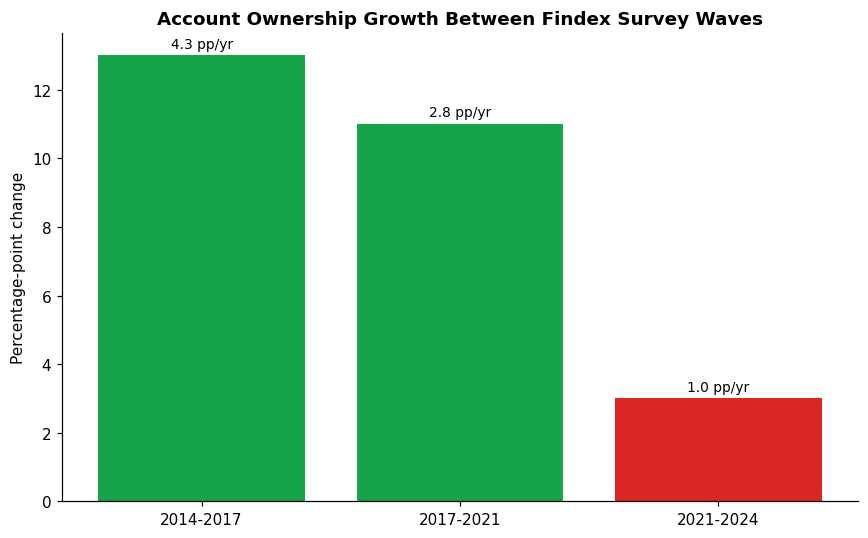

In [9]:
display(Image(str(FIG / "03_access_trajectory.png")))
display(Image(str(FIG / "04_growth_rates.png")))


**Key read:** Account ownership rose steadily from 22% (2014) to 46% (2021) — roughly
+3-4 percentage points (pp) per year — then **decelerated sharply to +3pp total** between 2021 and
2024 (46% → 49%, ~1pp/year), despite the launch of Telebirr (May 2021), Safaricom's market entry
(Aug 2022), and NFIS-II (Sep 2021) all falling inside that window. This is the "2021-2024
slowdown" the brief specifically asks us to investigate — addressed in Section 3.1 below.

### 3.1 Investigating the 2021-2024 Slowdown

Three plausible, non-exclusive explanations emerge from the enriched dataset:

1. **Mobile money adoption ≠ new account ownership.** Mobile Money Account Rate did grow (4.7% →
   9.45%, REC_0007/REC_0008), but off a small base — nowhere near enough alone to move the
   headline 49-56pp Account Ownership needle, and Ethiopia's Market Nuance D notes only ~0.5% of
   adults are mobile-money-only, i.e. most new mobile money users likely already had a bank
   account. Mobile money growth substituted for *usage* growth, not *access* growth.
2. **Supply-side access points remain thin.** Newly added REC_0034/REC_0035 show only ~14 bank
   branches and ~10 ATMs per 100,000 adults (2023) — far below the ~53 ATM/100k global average —
   so the traditional on-ramp to a bank account didn't expand nearly as fast as mobile subscriber
   growth did.
3. **Enabling infrastructure is still catching up.** Electricity access sits at 55.4% (REC_0036)
   and literacy at only ~52% (REC_0037, albeit a stale 2017 figure) — both hard constraints on
   who can realistically be onboarded, regardless of how many telecom products launch.

In short: **Telebirr and M-Pesa mainly deepened *usage* among people who could already access
formal services (largely urban, literate, banked), while the harder problem of first-time *access*
for rural/illiterate/off-grid populations did not move much in three years** — consistent with
NBE's own NDPS 2.0 admission of a persistent 24pp rural-urban usage gap (REC_0043).

## 4. Gender Analysis

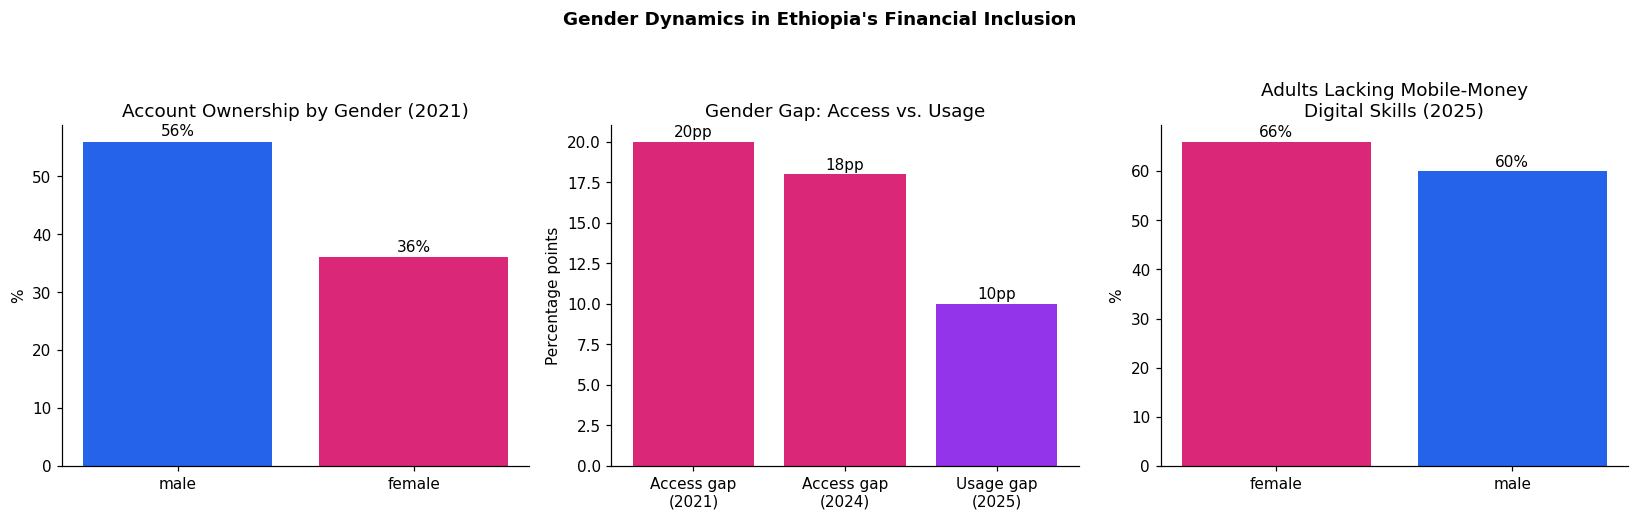

In [10]:
display(Image(str(FIG / "05_gender_analysis.png")))

**Key read:** The Access gender gap barely moved (20pp in 2021 → 18pp in 2024), but the
newly-added Usage gender gap is narrower (10pp, REC_0044) — i.e., **once a woman has an account,
her usage patterns are closer to parity than her odds of having an account in the first place.**
The digital-skills data (REC_0045/REC_0046) shows the real constraint may be broader than gender:
a majority of *both* men (60%) and women (66%) lack mobile-money digital skills, so gender
explains only part of the gap; general digital literacy is a bigger lever.

## 5. Usage (Digital Payments) Analysis

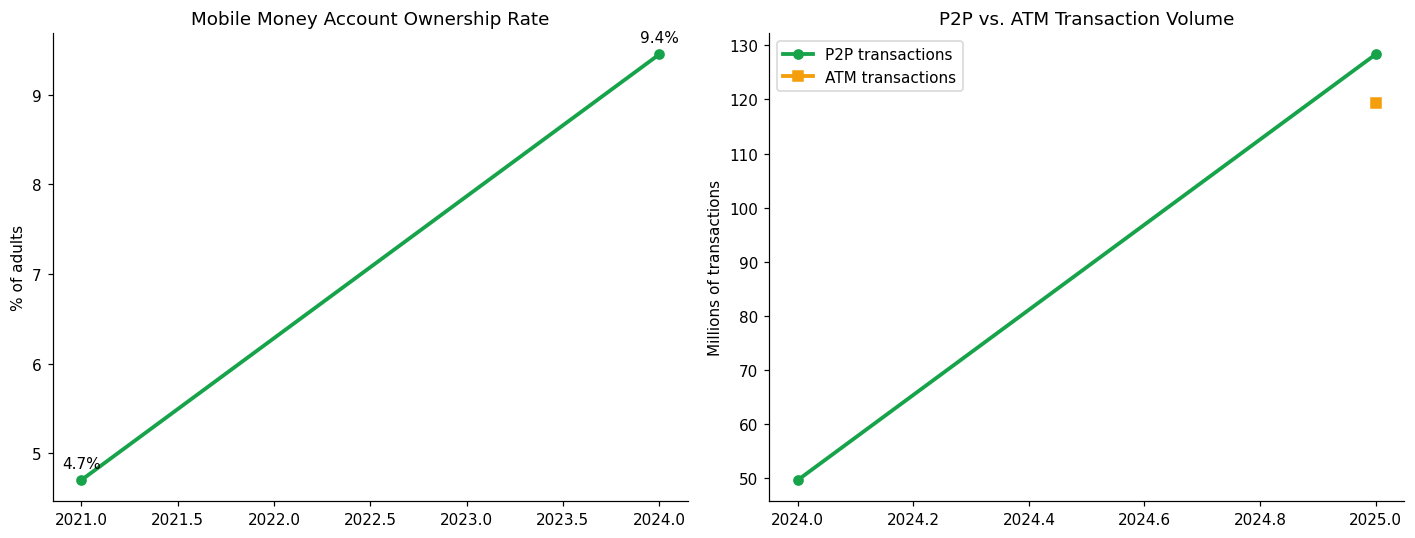

In [11]:
display(Image(str(FIG / "06_usage_trends.png")))

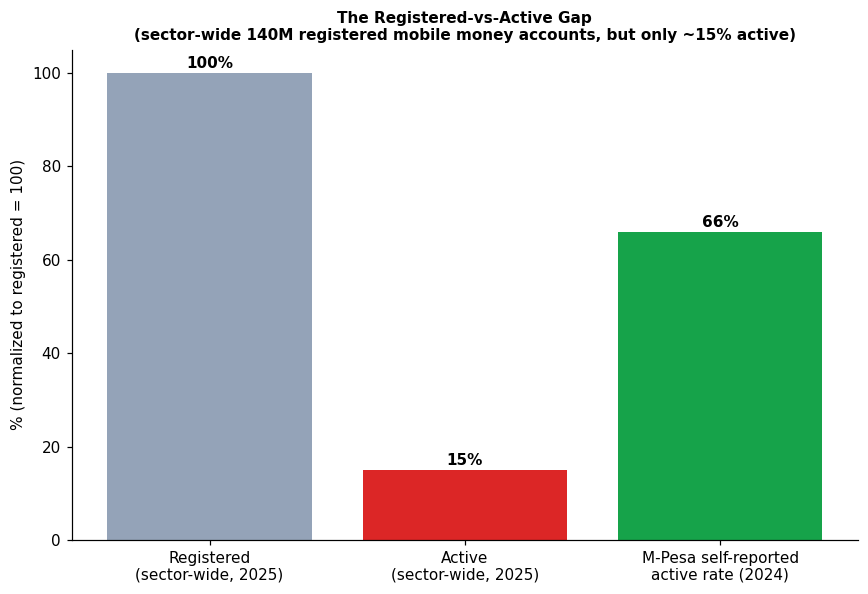

In [12]:
display(Image(str(FIG / "07_registered_vs_active.png")))

**Key read — the registered-vs-active gap:** Ethiopia has ~139.5 million *registered* mobile
money accounts (REC_0040) sector-wide as of 2025 — more than the entire adult population, implying
substantial duplicate/dormant registrations — yet NBE reports only **~15% of accounts and ~25% of
agents are actually active** (REC_0041/REC_0042). This starkly contradicts the 66% "activity rate"
Safaricom self-reports for M-Pesa alone (REC_0025) — a genuine **definitional inconsistency between
operator self-reports and regulator sector-wide figures** that any Usage forecast must be explicit
about (see Section 7, Data Quality).

## 6. Infrastructure and Enablers

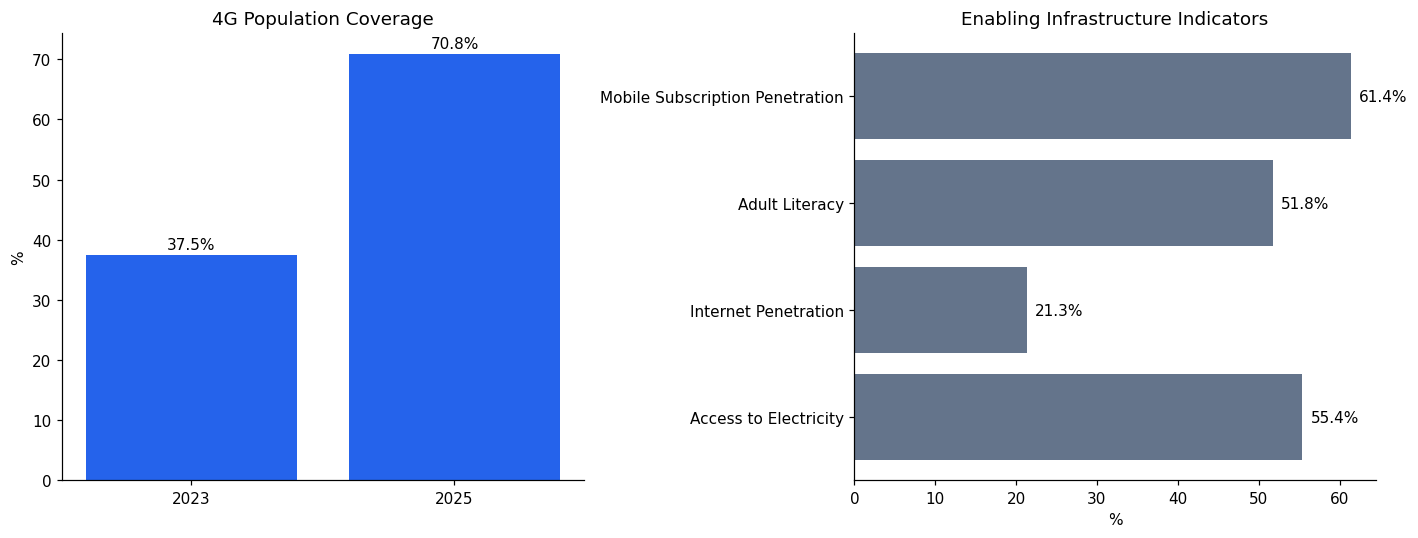

In [13]:
display(Image(str(FIG / "08_infrastructure.png")))

**Key read:** 4G coverage nearly doubled in two years (37.5% → 70.8%, REC_0009/REC_0010),
comfortably outpacing account-ownership growth over the same window — supporting the reading that
**network/device access is no longer the binding constraint**; electricity (55.4%) and literacy
(~52%) plausibly are. This makes ACC_ELECTRICITY and ACC_LITERACY strong *leading-indicator*
candidates for the forecasting model despite their single-year snapshots, precisely because they
change slowly and set a ceiling on how fast Access can realistically grow.

## 7. Event Timeline and Visual Analysis

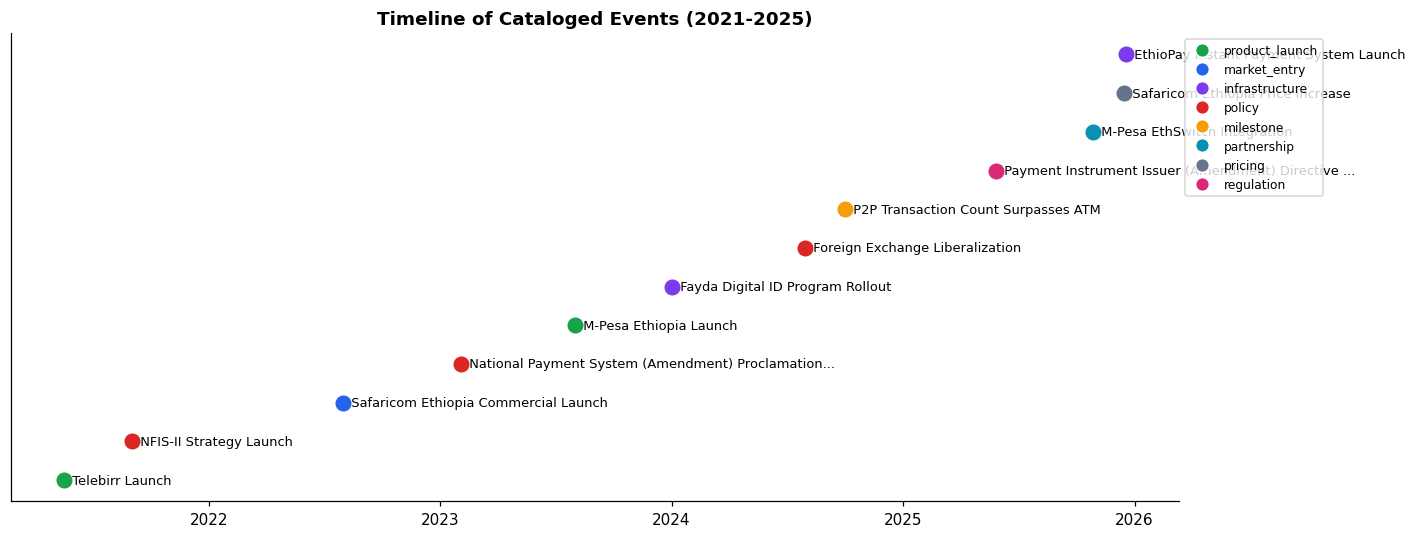

In [14]:
display(Image(str(FIG / "09_event_timeline.png")))

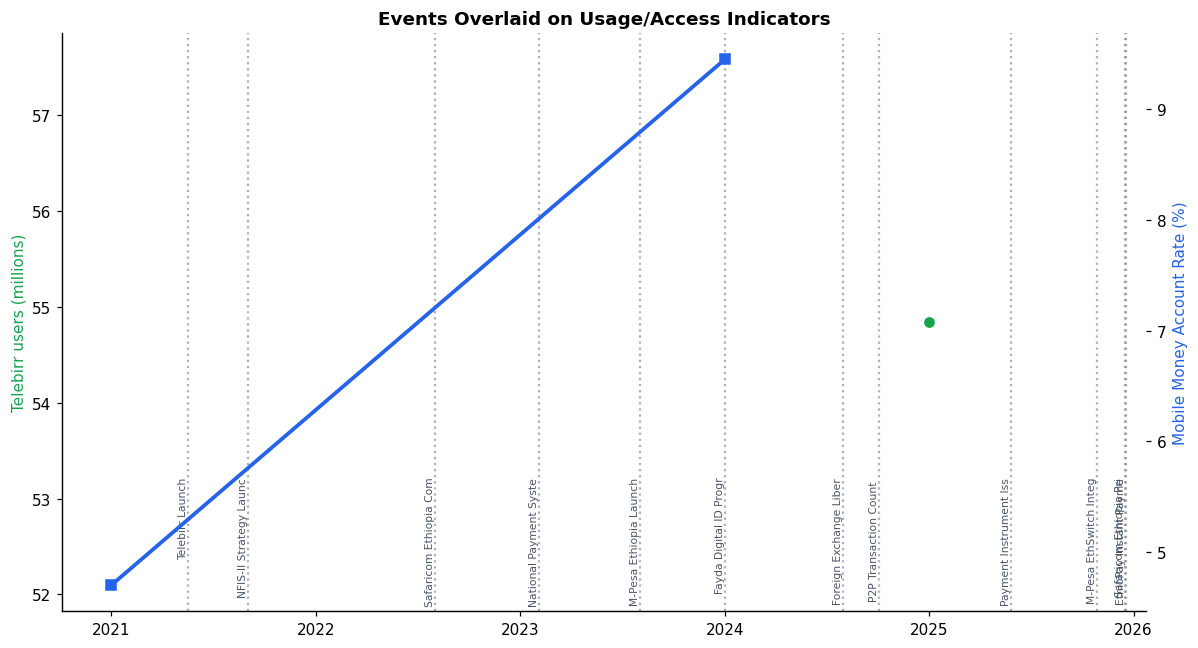

In [15]:
display(Image(str(FIG / "10_events_overlay.png")))

**Visual read against the brief's specific questions:**
- **Telebirr launch (May 2021):** Telebirr users (green) grew explosively in the years after
  launch, but the Mobile Money Account *rate* (blue, Findex-measured) only doubled from a small
  base by 2024 — again illustrating that huge product-level registration numbers did not
  translate 1:1 into Findex-measured inclusion.
- **M-Pesa entry (Aug 2023):** too recent relative to the next Findex wave (2024, only ~1 quarter
  later) for its effect to be visible in survey data yet — a forecasting-relevant lag issue.
- **Safaricom market entry (Aug 2022):** coincides with the acceleration of 4G coverage
  (REC_0009 → REC_0010), consistent with the impact_link IMP_0004 (Safaricom → ACC_4G_COV,
  `direct`, `medium` magnitude) already in the starter data.
- **Newly added EVT_0011 (Feb 2023 proclamation):** sits ~6 months before M-Pesa's actual launch —
  the legal precondition the starter dataset was missing (see IMP_0015/IMP_0016).

## 8. Correlation Analysis

**Important caveat:** given the sparse time series documented in Section 2, most indicator pairs
share only 1-2 overlapping years. A 2-point correlation is mathematically always ±1 and should
**not** be read as evidence of a real relationship — it is included for completeness and to make
the data limitation visible, not as a modeling input.

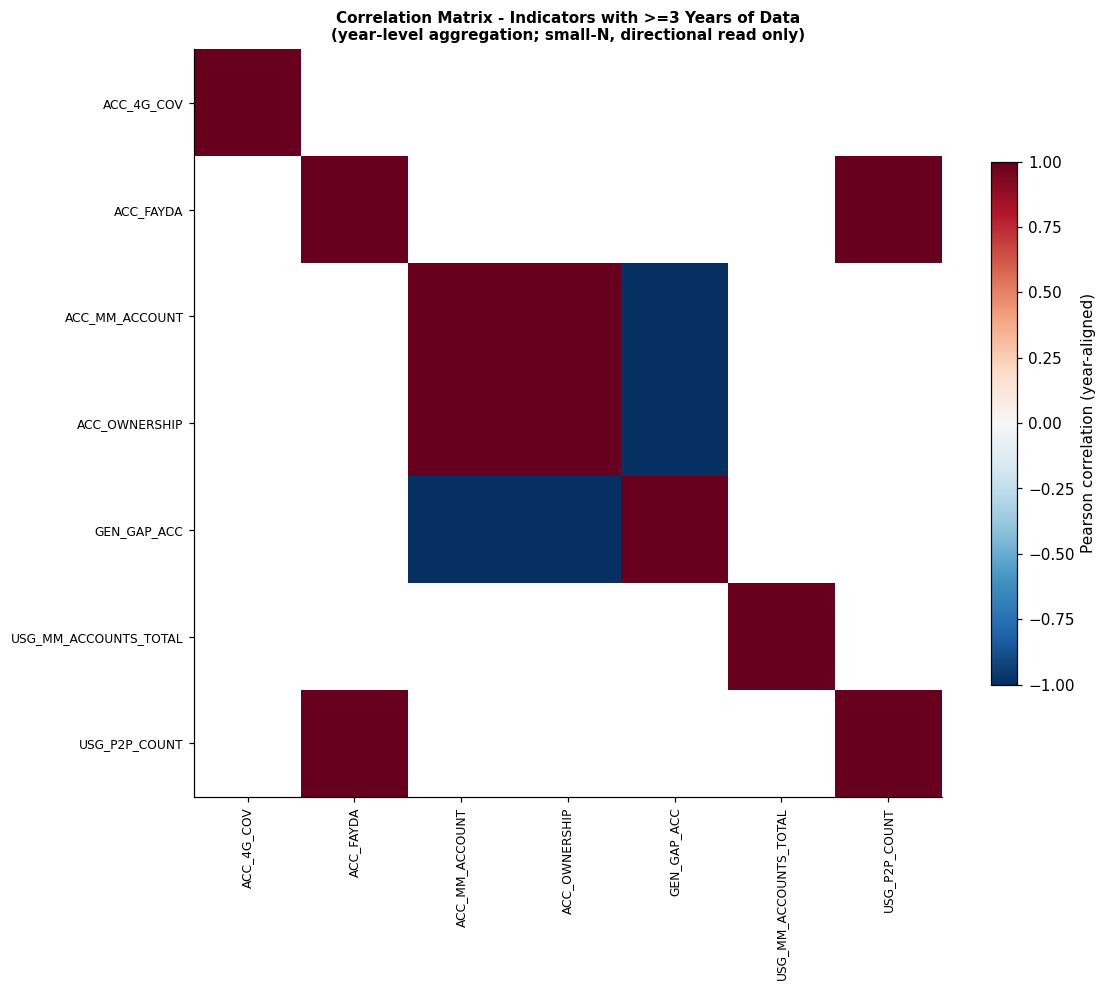

In [16]:
display(Image(str(FIG / "11_correlation_matrix.png")))

**What the existing `impact_link` records tell us instead:** since direct statistical
correlation is unreliable with this little data, the dataset's real analytical value for the
"what drives inclusion" question lies in the *expert/literature-based* `impact_link` records
(18 after enrichment). Summarizing by pillar and relationship type:

In [17]:
impact_summary = impact.groupby(["pillar","relationship_type"]).size().unstack(fill_value=0)
print(impact_summary)
print("\nEvidence basis distribution:")
print(impact["evidence_basis"].value_counts())


relationship_type  direct  enabling  indirect
pillar                                       
ACCESS                  3         2         0
AFFORDABILITY           1         0         2
GENDER                  0         1         1
USAGE                   6         1         1

Evidence basis distribution:
evidence_basis
literature     8
empirical      7
theoretical    3
Name: count, dtype: int64


USAGE is the pillar with the most modeled impact_links (mobile money launches feed usage
metrics directly and quickly), while ACCESS links are more often `enabling` with longer lags —
matching the slower-moving Access trajectory observed in Section 3.

## 9. Key Insights Summary

1. **Account ownership growth decelerated sharply post-2021** (+11pp in 2017-2021 → only +3pp in
   2021-2024) even as mobile money and 4G coverage surged — usage-side products deepened
   engagement for the already-included more than they expanded first-time access.
2. **The registered-vs-active gap is large and inconsistently reported**: ~139.5M registered
   mobile money accounts sector-wide but only ~15% active (NBE), versus a self-reported 66% active
   rate from a single operator (M-Pesa) — any Usage forecast needs to pick one consistent
   definition and disclose it.
3. **The Access gender gap (18-20pp) is roughly double the Usage gender gap (10pp)** — the barrier
   to opening an account is more gendered than the barrier to using one afterward, suggesting
   onboarding-stage interventions (ID, agent trust, account-opening requirements) matter more for
   gender equity than post-onboarding product design.
4. **Enabling infrastructure (electricity 55.4%, literacy ~52%) lags behind network coverage
   (4G 70.8%)** — connectivity is no longer the main bottleneck; power and literacy plausibly are,
   and both are new additions from Task 1 enrichment that weren't in the starter dataset at all.
5. **Digital-skill gaps are large for both genders** (66% female / 60% male lack mobile-money
   skills) — this is a broader capability constraint than the raw gender-gap figures alone would
   suggest, and points to a bigger role for digital-literacy programs (part of NFIS-II) than
   gender-targeted programs alone.
6. **The dataset itself is data-limited**: most indicators have only 1-2 observed years, several
   pillars (QUALITY, TRUST, DEPTH) have zero observations, and the one literacy figure available
   is 7 years stale — all of which bound how far a 2025-2027 forecast can be trusted without
   wide uncertainty intervals.


## 10. Data Quality Assessment & Limitations

- **Sparse time series:** ~85% of indicators (24 of 30 original + enriched indicator_codes with
  numeric values) have only 1 or 2 observed years — insufficient for standard trend/seasonality
  decomposition; any forecast model needs to lean on event-driven, intervention-style methods
  (regression with dummy/impact variables) rather than pure time-series extrapolation, matching
  the task's suggested "Regression modeling with intervention variables" approach.
- **Missing pillars:** QUALITY (service reliability/uptime), TRUST (fraud/complaints), and DEPTH
  (savings/credit/insurance) have zero observations in the dataset even after enrichment — a
  genuine coverage gap that limits any holistic financial-inclusion narrative, not just the two
  forecast targets.
- **Definitional inconsistency in Usage:** as documented in Section 5, "active user" means
  different things to different sources (operator self-report vs. regulator sector-wide), and this
  was not flagged anywhere in the original dataset's `notes` field.
- **Stale literacy data:** REC_0037 (51.8%) is the latest verifiable World Bank/UNESCO figure but
  dates to 2017; more recent unsourced estimates (~66%) exist online but could not be verified to
  a primary source and were deliberately excluded rather than guessed (see enrichment log).
- **No urban/rural breakdown of the headline Findex Account Ownership rate** — only the aggregate
  NBE-reported *usage* gap (24pp) is available; the Access-side urban/rural split would require
  paid/registration-gated Findex microdata not accessed for this challenge.
- **Small-N correlation risk:** as shown in Section 8, correlations computed on 1-2 shared years
  are not statistically meaningful and are reported only for transparency.

### Hypotheses for the impact-modeling phase
- H1: Enabling infrastructure (electricity, literacy) will out-predict telecom-launch dummies for
  *Access*, while telecom-launch dummies will out-predict infrastructure for *Usage*.
- H2: A consistent, regulator-sourced "active account" definition (not operator self-reports) will
  produce a materially lower and more realistic Usage forecast than a naive extrapolation of
  registered-account growth.
- H3: The Access gender gap will close more slowly than the Usage gender gap over 2025-2027, since
  it is tied to slower-moving structural enablers (ID, literacy) rather than product adoption.


## Next Steps (Task 3+)
Carry indicators `ACC_OWNERSHIP`, `ACC_MM_ACCOUNT`, `ACC_ELECTRICITY`, `ACC_LITERACY`,
`USG_ACTIVE_ACCOUNT_SHARE`, and the enriched `impact_link` table forward into the impact-modeling
and forecasting tasks. Prioritize resolving the registered-vs-active Usage definition before
forecasting, since it changes the 2025-2027 Usage trajectory substantially.